 accuracy: 65.54%



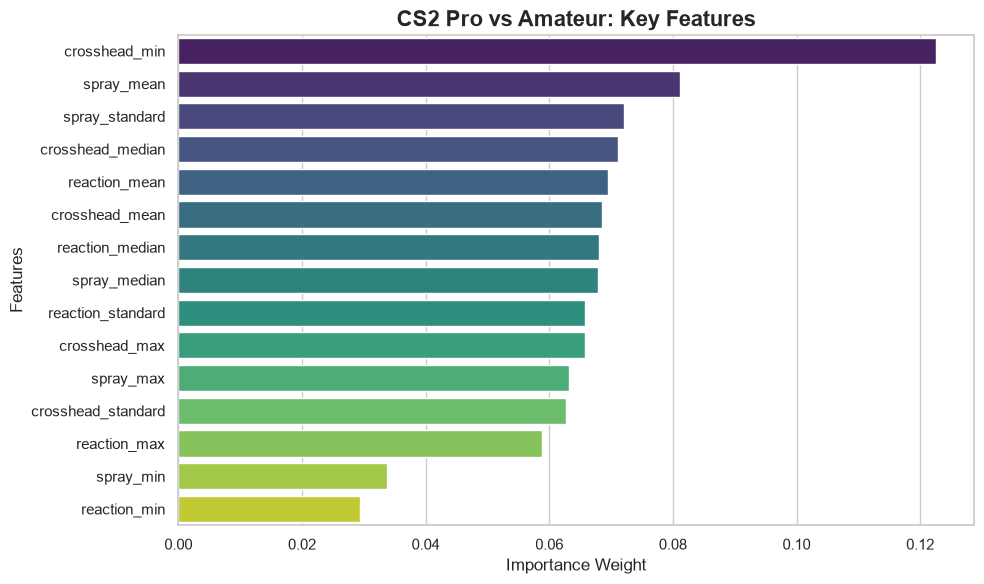

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

data_path = r"data\data.csv"

df = pd.read_csv(r"data\data.csv").dropna()
X = df.drop(columns = ["is_pro","player_name"])
y = df["is_pro"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
model = RandomForestClassifier(n_estimators=100, random_state=1)
model.fit(X_train, y_train)


print(f" accuracy: {model.score(X_test, y_test) * 100:.2f}%\n")

feature_importances = pd.DataFrame({
    'name': X.columns,
    'weight': model.feature_importances_
}).sort_values(by='weight', ascending=False)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances, x='weight', y='name', hue='name', palette='viridis', legend=False)
plt.title('CS2 Pro vs Amateur: Key Features', fontsize=16, fontweight='bold')
plt.xlabel('Importance Weight', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=1),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
new_accuracy = best_model.score(X_test, y_test)

print(f"best model: {grid_search.best_params_}")
print(f"accuracy: {new_accuracy * 100:.2f}%！")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
best model: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
accuracy: 57.43%！
